# TCR–Epitope Binding Prediction: Baseline Analysis

This notebook presents the results of a classical ML baseline pipeline to predict whether a T-cell receptor (TCR) binds a given epitope.

**Data:** iggytop database — 300k+ TCR–epitope positive pairs extracted using `scirpy.get.airr_context`  
**Negatives:** generated by mismatched pairing (each TCR paired with a random epitope it did not come from)  
**Features:** ESM2 protein language model embeddings only — no hand-crafted features  
**Models:** Logistic Regression (linear baseline) and Random Forest (non-linear baseline)  
**Tracking:** all experiments logged with MLflow

## Setup

In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import shap
from sklearn.metrics import roc_curve, precision_recall_curve

# ── CONFIG — adjust paths if needed ──────────────────────────────────────────
PROJECT_DIR = os.path.expanduser('~/projectsZHAW/VT1/iggytop')
OUTPUTS_DIR = os.path.join(PROJECT_DIR, 'outputs/outputs_v1')
MLFLOW_URI  = f'sqlite:///{OUTPUTS_DIR}/mlflow.db'
SHAP_PKL    = os.path.join(OUTPUTS_DIR, 'shap_data.pkl')
RF_PKL      = os.path.join(OUTPUTS_DIR, 'random_forest.pkl')
LR_PKL      = os.path.join(OUTPUTS_DIR, 'logistic_regression.pkl')

# print(f'Outputs dir : {OUTPUTS_DIR}')
# print(f'MLflow URI  : {MLFLOW_URI}')
# print(f'shap_data   : {chr(10003) if os.path.exists(SHAP_PKL) else chr(10007) + " MISSING"}')
# print(f'RF model    : {chr(10003) if os.path.exists(RF_PKL)   else chr(10007) + " MISSING"}')
# print(f'LR model    : {chr(10003) if os.path.exists(LR_PKL)   else chr(10007) + " MISSING"}')

## How Sequences Were Embedded

Both the CDR3β and epitope sequences were converted into fixed-length numerical vectors using [ESM2](https://github.com/facebookresearch/esm) (`facebook/esm2_t6_8M_UR50D`), a protein language model pre-trained on millions of protein sequences.

Each sequence is tokenized at the amino acid level. The model outputs a hidden state for each position; we take the **mean across positions** (mean-pooling) weighted by the attention mask to ignore padding. This gives a 320-dimensional vector per sequence. TCR and epitope embeddings are concatenated → **640 features total**.

In [2]:
# This is the embedding function used in tcr_epitope_minimal.py
# Shown here for reference — embeddings were pre-computed on the cluster

def embed_sequences(seqs, model, tokenizer, device, batch_size=64):
    """
    Embed amino-acid sequences using ESM2.
    Mean-pool over sequence length, weighted by attention mask (ignores padding).
    Returns: np.ndarray of shape (N, 320)
    """
    unique_seqs = list(dict.fromkeys(seqs))  # deduplicate
    cache = {}

    for i in range(0, len(unique_seqs), batch_size):
        batch  = unique_seqs[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True,
                           truncation=True, max_length=50).to(device)
        with torch.no_grad():
            out = model(**inputs)
        # weighted mean-pool
        mask = inputs['attention_mask'].unsqueeze(-1).float()   # (B, L, 1)
        emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1)  # (B, 320)
        for s, e in zip(batch, emb.cpu().numpy()):
            cache[s] = e

    return np.array([cache[s] for s in seqs])

# Final feature matrix: TCR embedding + epitope embedding concatenated
# X = np.concatenate([tcr_emb, epi_emb], axis=1)  →  shape (N, 640)

## Load Data & Models

The test set, predictions, and models were saved after training on the cluster and copied locally.

In [3]:
# Load SHAP data (X_test, y_test, rf_probs, run_id)
with open(SHAP_PKL, 'rb') as f:
    shap_data = pickle.load(f)

X_test   = shap_data['X_test']
y_test   = shap_data['y_test']
rf_probs = shap_data['rf_probs']
run_id   = shap_data['run_id']

# Load models from local pickle (avoids MLflow artifact path issues)
with open(RF_PKL, 'rb') as f:
    rf = pickle.load(f)

with open(LR_PKL, 'rb') as f:
    lr = pickle.load(f)

lr_probs = lr.predict_proba(X_test)[:, 1]

print(f'X_test shape : {X_test.shape}')
print(f'y_test shape : {y_test.shape}')
print(f'Class balance: {sum(y_test==0)} neg / {sum(y_test==1)} pos')
print(f'Run ID       : {run_id}')

/home/helen/projectsZHAW/VT1/iggytop/.venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/helen/projectsZHAW/VT1/iggytop/.venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/helen/projectsZHAW/VT1/iggytop/.venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unp

X_test shape : (120361, 640)
y_test shape : (120361,)
Class balance: 60181 neg / 60180 pos
Run ID       : e698c2bca561441898c7e49b8c04825c


In [4]:
mlflow.set_tracking_uri(MLFLOW_URI)

# Load the specific run that generated our data
run     = mlflow.get_run(run_id)
metrics = run.data.metrics
params  = run.data.params

print(f'Run name : {run.info.run_name}')
print(f'Status   : {run.info.status}')
print(f'\nParameters:')
for k, v in params.items():
    print(f'  {k:20s}: {v}')

Run name : intrigued-seal-61
Status   : FINISHED

Parameters:
  esm_model           : facebook/esm2_t6_8M_UR50D
  max_samples         : None
  neg_ratio           : 1.0
  random_seed         : 42


## Model Comparison

We compare two classical ML models trained on the ESM2 feature matrix. **AUC-ROC** is the primary metric — it measures how well the model ranks binding pairs above non-binding ones.

In [5]:
metric_names = ['auc', 'aupr', 'f1', 'precision', 'recall', 'specificity', 'accuracy', 'optimal_f1']

comparison_data = {'Logistic Regression': {}, 'Random Forest': {}}
for m in metric_names:
    if f'logistic_regression_{m}' in metrics:
        comparison_data['Logistic Regression'][m] = metrics[f'logistic_regression_{m}']
    if f'random_forest_{m}' in metrics:
        comparison_data['Random Forest'][m] = metrics[f'random_forest_{m}']

comparison = pd.DataFrame(comparison_data)

print('=' * 60)
print('MODEL COMPARISON')
print('=' * 60)
print(comparison.round(4).to_string())
print('=' * 60)

auc_lr = comparison.loc['auc', 'Logistic Regression']
auc_rf = comparison.loc['auc', 'Random Forest']
winner = 'Random Forest' if auc_rf > auc_lr else 'Logistic Regression'
print(f'\nWinner by AUC: {winner} (margin: {abs(auc_rf - auc_lr):.4f})')

MODEL COMPARISON
             Logistic Regression  Random Forest
auc                       0.5050         0.7830
aupr                      0.5092         0.7974
f1                        0.4897         0.7104
precision                 0.4983         0.6673
recall                    0.4814         0.7594
specificity               0.5153         0.6214
accuracy                  0.4983         0.6904
optimal_f1                0.6667         0.7252

Winner by AUC: Random Forest (margin: 0.2780)


The ROC curve shows the trade-off between true positive rate and false positive rate. The PR curve is more informative for imbalanced datasets. Random Forest substantially outperforms Logistic Regression, indicating the relationship between ESM2 features and binding is **non-linear**.

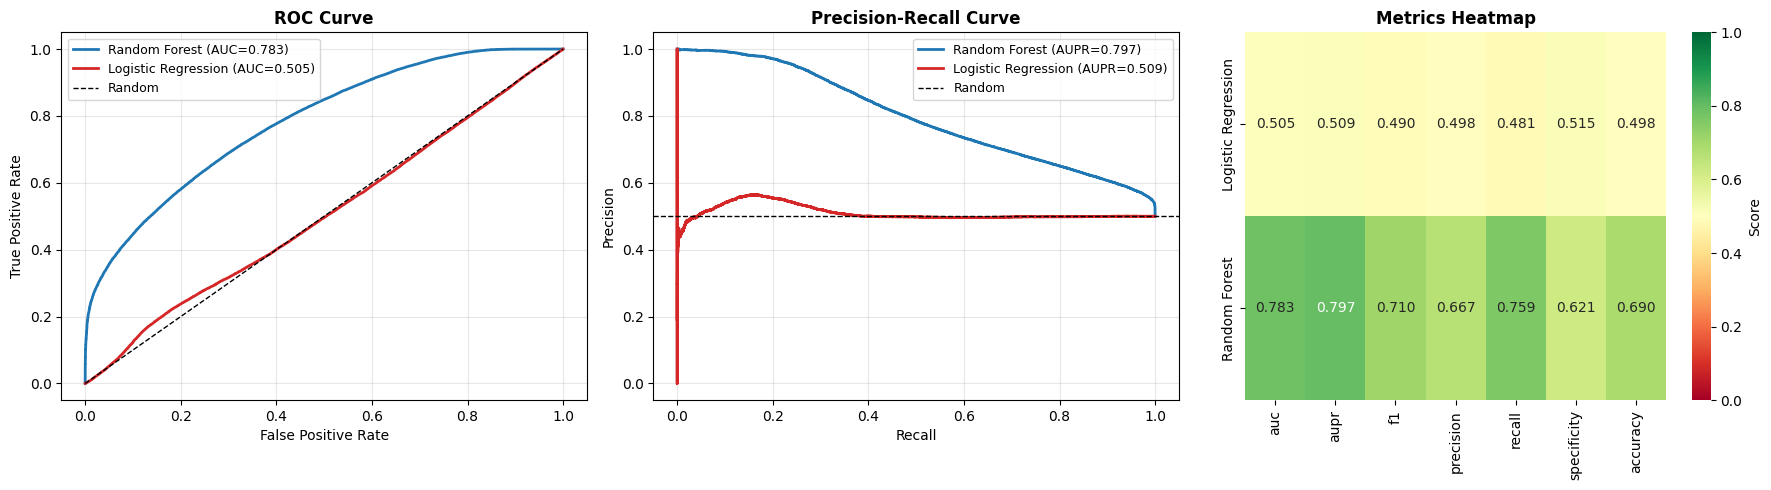

Saved to /home/helen/projectsZHAW/VT1/iggytop/outputs/outputs_v1/metrics_visualization.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
for probs, label, color in [
    (rf_probs, f'Random Forest (AUC={auc_rf:.3f})', '#1f77b4'),
    (lr_probs, f'Logistic Regression (AUC={auc_lr:.3f})', '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=label, color=color, lw=2)
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# PR curves
aupr_rf = metrics.get('random_forest_aupr', 0)
aupr_lr = metrics.get('logistic_regression_aupr', 0)
for probs, label, color in [
    (rf_probs, f'Random Forest (AUPR={aupr_rf:.3f})', '#1f77b4'),
    (lr_probs, f'Logistic Regression (AUPR={aupr_lr:.3f})', '#d62728'),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, label=label, color=color, lw=2)
axes[1].axhline(y=0.5, color='k', linestyle='--', lw=1, label='Random')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Heatmap
heatmap_data = comparison.drop('optimal_f1', errors='ignore')
sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=axes[2], cbar_kws={'label': 'Score'})
axes[2].set_title('Metrics Heatmap', fontweight='bold')

plt.tight_layout()
out_path = os.path.join(OUTPUTS_DIR, 'metrics_visualization.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out_path}')

## Summary

Random Forest with ESM2 embeddings achieves **AUC ~0.78** as a baseline, well above random (0.5). Logistic Regression (~0.50 AUC) fails to learn, confirming the feature–label relationship is non-linear. These baselines establish a reference point for future deep learning models.

In [10]:
print('=' * 60)
print('FULL RESULTS SUMMARY')
print('=' * 60)
print(f'\nDataset')
print(f'  Positives : {metrics.get("n_positives", "N/A"):.0f}')
print(f'  Total     : {metrics.get("n_total", "N/A"):.0f}')
print(f'  Features  : {int(metrics.get("feature_dim", 0))} (ESM2 only)')
print(f'  Train     : {metrics.get("train_size", "N/A"):.0f}')
print(f'  Test      : {metrics.get("test_size", "N/A"):.0f}')
print(f'\nModel Performance (test set)')
print(f'  {"Metric":<15} {"LR":>10} {"RF":>10}')
print(f'  {"-"*35}')
for m in ['auc', 'aupr', 'f1', 'accuracy', 'precision', 'recall']:
    lr_val = metrics.get(f'logistic_regression_{m}', float('nan'))
    rf_val = metrics.get(f'random_forest_{m}', float('nan'))
    print(f'  {m:<15} {lr_val:>10.4f} {rf_val:>10.4f}')
print(f'  {"-"*35}')
print(f'  Winner by AUC     : {winner}')
print('=' * 60)

FULL RESULTS SUMMARY

Dataset
  Positives : 300901
  Total     : 601802
  Features  : 640 (ESM2 only)
  Train     : 481441
  Test      : 120361

Model Performance (test set)
  Metric                  LR         RF
  -----------------------------------
  auc                 0.5050     0.7830
  aupr                0.5092     0.7974
  f1                  0.4897     0.7104
  accuracy            0.4983     0.6904
  precision           0.4983     0.6673
  recall              0.4814     0.7594
  -----------------------------------
  Winner by AUC     : Random Forest


This UMAP is computed on the full 640-dimensional feature vector used by the Random Forest — the concatenation of TCR and epitope ESM2 embeddings — so each point represents a TCR–epitope pair, and any visible structure reflects the joint biochemical compatibility captured by the model.

In [11]:
# ── UMAP on the full concatenated embedding (TCR + epitope = 640 dims) ────
# This is what the Random Forest actually learned from
%pip install umap-learn plotly

import umap
import plotly.express as px
import pandas as pd
import numpy as np

# ── 1. Subsample for speed (UMAP on 120k points is slow in a notebook) ────
N_VIZ = 3000
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_test), size=N_VIZ, replace=False)

X_viz = X_test[idx]          # (3000, 640)  — ESM2 embeddings
y_viz = y_test[idx]           # 0 = non-binding, 1 = binding

print("Running UMAP on TCR + epitope embeddings (640 dims)...")
reducer_full = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                          random_state=42, n_jobs=1)
full_2d = reducer_full.fit_transform(X_viz)   # (3000, 640) → (3000, 2)

df_full = pd.DataFrame({
    "UMAP 1"  : full_2d[:, 0],
    "UMAP 2"  : full_2d[:, 1],
    "label"   : ["binding" if l == 1 else "non-binding" for l in y_viz],
    "prob_rf" : rf.predict_proba(X_viz)[:, 1].round(3),
})

# ── colored by true label ─────────────────────────────────────────────────
fig3 = px.scatter(
    df_full,
    x="UMAP 1", y="UMAP 2",
    color="label",
    color_discrete_map={"binding": "#534AB7", "non-binding": "#BA7517"},
    hover_data={"prob_rf": True, "UMAP 1": False, "UMAP 2": False},
    opacity=0.6,
    title="ESM2 TCR + epitope embeddings — UMAP colored by binding label",
    labels={"label": ""},
    template="plotly_white",
)
fig3.update_traces(marker=dict(size=5))
fig3.show()

# ── colored by RF probability ─────────────────────────────────────────────
fig4 = px.scatter(
    df_full,
    x="UMAP 1", y="UMAP 2",
    color="prob_rf",
    color_continuous_scale="RdYlBu_r",
    range_color=[0, 1],
    opacity=0.6,
    title="ESM2 TCR + epitope embeddings — UMAP colored by RF binding probability",
    labels={"prob_rf": "P(binding)"},
    template="plotly_white",
)
fig4.update_traces(marker=dict(size=5))
fig4.show()


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Running UMAP on TCR + epitope embeddings (640 dims)...


The model’s predicted probabilities align with this structure. Regions enriched for binding are assigned higher probabilities, while more mixed regions show intermediate confidence around P(binding) ≈ 0.5, reflecting greater uncertainty. This suggests that the model is leveraging the underlying structure of the embedding space to make its predictions.

## SHAP Feature Importance

SHAP (SHapley Additive exPlanations) quantifies the contribution of each feature to individual predictions. Since our 640 features are ESM2 embedding dimensions (320 for TCR + 320 for epitope), SHAP tells us which embedding dimensions are most predictive, and whether **TCR or epitope representations** carry more information about binding.

In [7]:
# Subsample for SHAP (fast enough for RF)
N_SHAP = 500
rng = np.random.default_rng(42)
idx = rng.choice(len(X_test), size=N_SHAP, replace=False)
X_shap = X_test[idx]

print(f'Computing SHAP values on {N_SHAP} samples ...')
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

# Use positive class shap values
# sv = shap_values[1] if isinstance(shap_values, list) else shap_values
sv = shap_values[:, :, 1]
feature_importance = np.abs(sv).mean(axis=0)
sorted_idx         = np.argsort(feature_importance)[::-1]

print(f'SHAP values shape: {sv.shape}')
print(f'Feature dim: {X_shap.shape[1]} (320 TCR + 320 epitope)')

Computing SHAP values on 500 samples ...
SHAP values shape: (500, 640)
Feature dim: 640 (320 TCR + 320 epitope)


The dot plot shows both the magnitude and direction of each feature's effect: red = high feature value, blue = low.

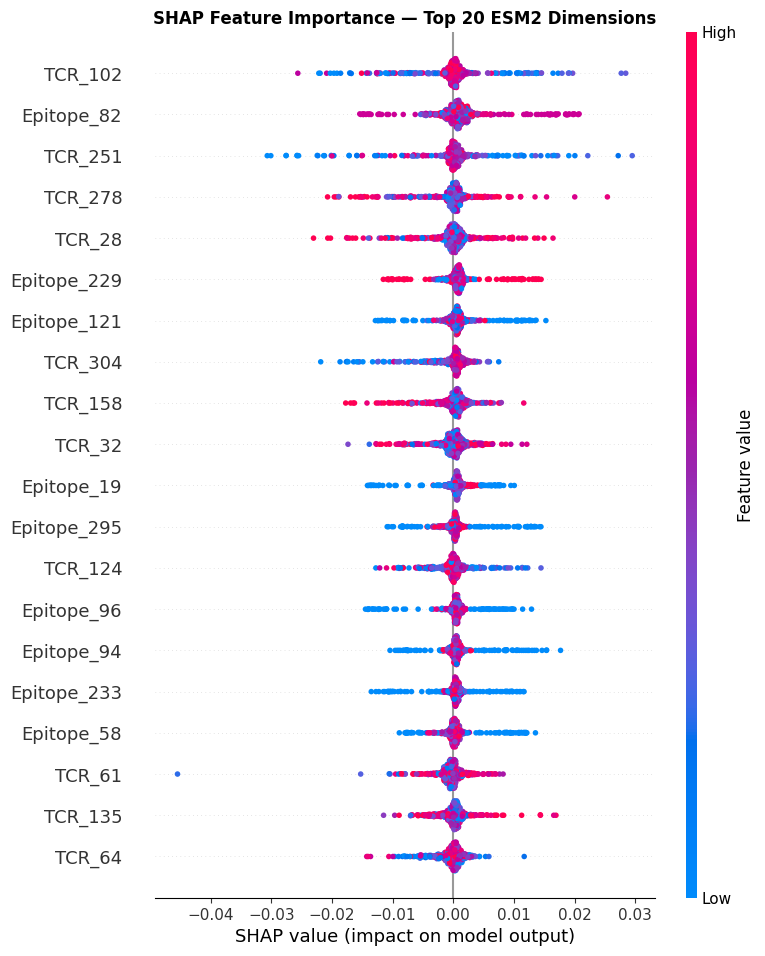

✓ Saved to outputs/shap_summary_dot.png


In [8]:
EMB_DIM = 320
feature_names = (
    [f'TCR_{i}'     for i in range(EMB_DIM)] +
    [f'Epitope_{i}' for i in range(EMB_DIM)]
)

shap.summary_plot(sv, X_shap, feature_names=feature_names, max_display=20, show=False)
plt.title('SHAP Feature Importance — Top 20 ESM2 Dimensions', fontweight='bold')
out_path = os.path.join(OUTPUTS_DIR, 'shap_summary.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved to outputs/shap_summary_dot.png")

The bar plot shows mean absolute SHAP values — the higher, the more that dimension influences predictions on average.

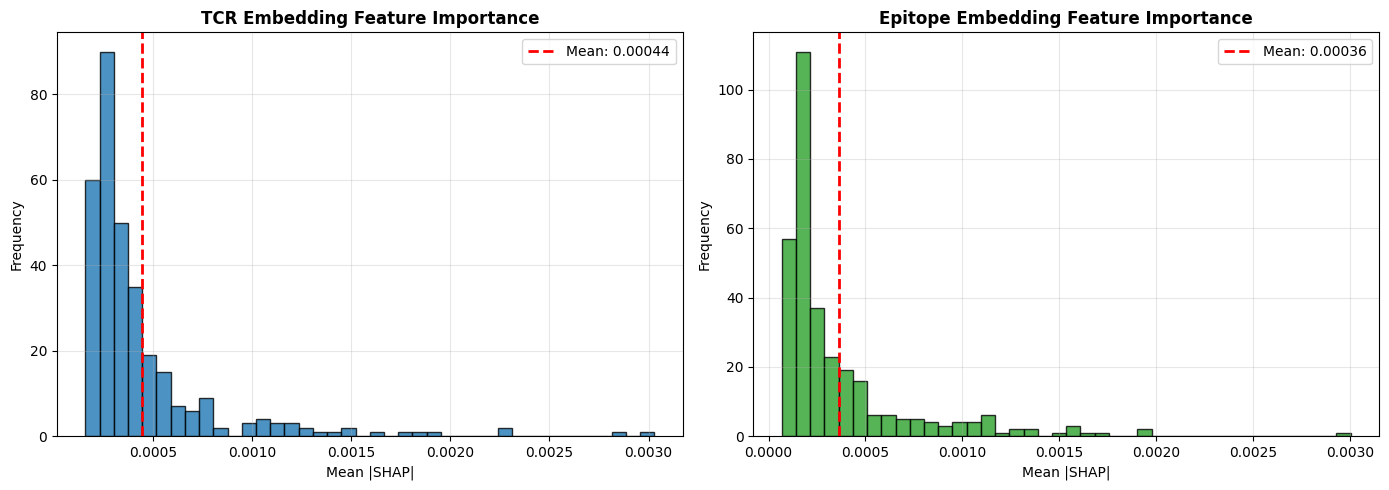

TCR importance    : 0.000443
Epitope importance: 0.000365
Ratio (TCR/Epi)   : 1.21x
TCR features are more informative for binding prediction


In [9]:
# TCR vs Epitope importance
tcr_importance = feature_importance[:EMB_DIM].mean()
epi_importance = feature_importance[EMB_DIM:].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feats, label, color in [
    (axes[0], feature_importance[:EMB_DIM], 'TCR Embedding',     '#1f77b4'),
    (axes[1], feature_importance[EMB_DIM:], 'Epitope Embedding', '#2ca02c'),
]:
    ax.hist(feats, bins=40, alpha=0.8, color=color, edgecolor='black')
    ax.axvline(feats.mean(), color='red', linestyle='--', lw=2,
               label=f'Mean: {feats.mean():.5f}')
    ax.set_title(f'{label} Feature Importance', fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(OUTPUTS_DIR, 'shap_tcr_vs_epitope.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'TCR importance    : {tcr_importance:.6f}')
print(f'Epitope importance: {epi_importance:.6f}')
print(f'Ratio (TCR/Epi)   : {tcr_importance/epi_importance:.2f}x')
if tcr_importance > epi_importance:
    print('TCR features are more informative for binding prediction')
else:
    print('Epitope features are more informative for binding prediction')